In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.shape

(9800, 18)

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [5]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [6]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [7]:
df['Year'] = df['Order Date'].dt.year

In [8]:
df[['Order Date', 'Year']].head()

,Order Date,Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


In [9]:
df['Year'].unique()

array([2017, 2016, 2015, 2018], dtype=int32)

In [10]:
df['Month'] = df['Order Date'].dt.month

In [11]:
df[['Order Date', 'Month']].head()

,Order Date,Month
0,2017-11-08,11
1,2017-11-08,11
2,2017-06-12,6
3,2016-10-11,10
4,2016-10-11,10


In [12]:
df['Quarter'] = df['Order Date'].dt.quarter

In [13]:
df[['Order Date', 'Month', 'Quarter']].head()

,Order Date,Month,Quarter
0,2017-11-08,11,4
1,2017-11-08,11,4
2,2017-06-12,6,2
3,2016-10-11,10,4
4,2016-10-11,10,4


In [14]:
df['Week_Number'] = df['Order Date'].dt.isocalendar().week

In [15]:
df[['Order Date', 'Week_Number']].head()

,Order Date,Week_Number
0,2017-11-08,45
1,2017-11-08,45
2,2017-06-12,24
3,2016-10-11,41
4,2016-10-11,41


In [16]:
df['Day_Of_Week'] = df['Order Date'].dt.day_name()

In [17]:
df[['Order Date', 'Day_Of_Week']].head()

,Order Date,Day_Of_Week
0,2017-11-08,Wednesday
1,2017-11-08,Wednesday
2,2017-06-12,Monday
3,2016-10-11,Tuesday
4,2016-10-11,Tuesday


In [18]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

In [19]:
df[['Month', 'Season']].head()

,Month,Season
0,11,Autumn
1,11,Autumn
2,6,Summer
3,10,Autumn
4,10,Autumn


In [20]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Quarter           0
Week_Number       0
Day_Of_Week       0
Season            0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

### Data Quality Check

The dataset contains 9,800 records and 18 original features. Missing value analysis revealed 11 missing values in the Postal Code column, while all other columns were complete. Since Postal Code is not required for sales forecasting, anomaly detection, or product demand segmentation, these records were retained. Duplicate row analysis showed that the dataset contains no duplicate records.


In [22]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [23]:
weekly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='W')
)['Sales'].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [24]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum().reset_index()

monthly_sales.head()

/tmp/ipykernel_58/1366809805.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Order Date', freq='M')


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [25]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

### Which product category generates the highest total revenue?

Technology generated the highest total revenue with sales of approximately $827,456, followed by Furniture ($728,659) and Office Supplies ($705,422). This indicates that technology products contribute the most to the company's overall sales performance and should be a key focus area for demand forecasting and inventory planning.


In [26]:
region_year_sales = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()

region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


### Which region has the most consistent sales growth over 4 years?

The East region demonstrated the most consistent sales growth over the four-year period. Sales increased steadily from approximately $127,653 in 2015 to $210,129 in 2018 without any year-over-year decline. This suggests a stable and growing customer base, making the East region an attractive area for future inventory and expansion planning.


In [27]:
df['Shipping_Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

df['Shipping_Days'].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping_Days, dtype: float64

### What is the average time between Order Date and Ship Date?

The average shipping time is approximately 3.96 days, with a median of 4 days. Most orders are delivered within 3 to 5 days, indicating a relatively efficient fulfillment process. The maximum observed shipping time is 7 days.


In [28]:
df.groupby('Region')['Shipping_Days'].mean().sort_values(ascending=False)

Region
Central    4.065876
South      3.961202
West       3.930255
East       3.910233
Name: Shipping_Days, dtype: float64

### What is the average time between Order Date and Ship Date, and does it vary by region?

The average shipping time across all orders is approximately 3.96 days. Regional analysis shows only minor differences in delivery times. The Central region has the highest average shipping time at 4.07 days, while the East region has the lowest at 3.91 days. Overall, shipping performance appears consistent across regions, with no significant regional delays observed.


In [29]:
monthly_year_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_year_sales.head(15)

,Year,Month,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


In [30]:
seasonality_table = df.pivot_table(
    values='Sales',
    index='Month',
    columns='Year',
    aggfunc='sum'
)

seasonality_table

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


### Are there months that consistently spike across all years?

Yes. Strong seasonality is visible in the sales data. September, November, and December consistently generate some of the highest sales across all four years. November is the strongest month overall, reaching the highest sales values in every year of the dataset. This pattern likely reflects holiday shopping periods, promotional campaigns, and year-end purchasing behavior. Businesses should plan inventory and staffing levels accordingly during these peak-demand months.


# Task 2 – Time Series Analysis & Decomposition

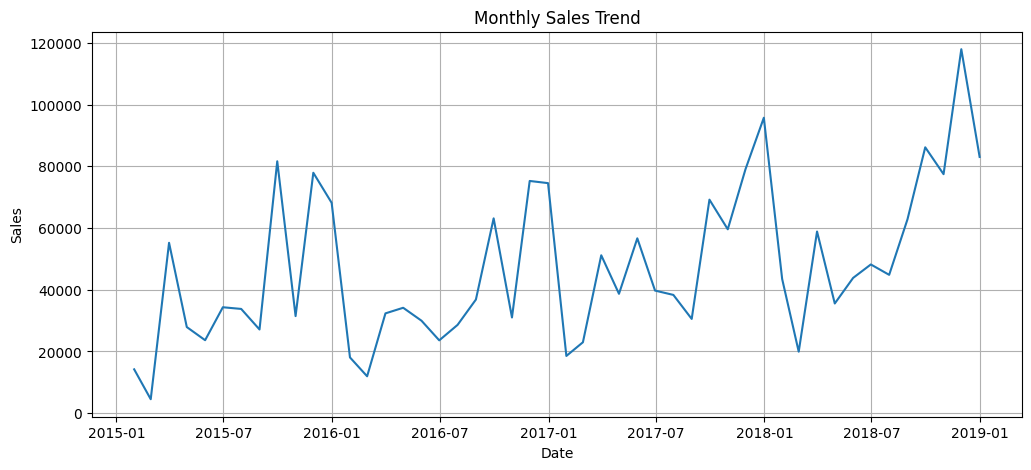

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.savefig("monthly_sales_trend.png", bbox_inches="tight", dpi=300)
plt.show()

### Monthly Sales Trend Analysis

The monthly sales trend shows an overall upward growth pattern from 2015 to 2018. Although sales fluctuate considerably from month to month, the peak sales values increase over time, indicating business growth. Higher sales are particularly visible during the later months of each year, suggesting the presence of seasonal demand patterns.


In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

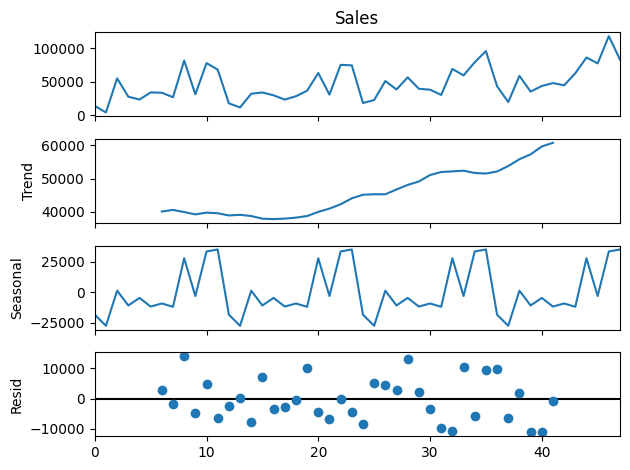

In [33]:
decomposition = seasonal_decompose(
    monthly_sales['Sales'],
    model='additive',
    period=12
)

decomposition.plot();

### Time Series Decomposition Analysis

The decomposed time series reveals three important patterns. The trend component shows a steady increase in sales over the four-year period, confirming long-term business growth. The seasonal component exhibits recurring peaks and troughs, indicating that certain months consistently experience higher or lower sales. The residual component appears randomly distributed around zero, suggesting that most systematic patterns have been successfully captured by the trend and seasonal components.


In [34]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales['Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


### Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller test produced an ADF statistic of -4.416 and a p-value of 0.000278. Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. Therefore, the monthly sales series can be considered stationary, indicating that forecasting models can be applied without significant concerns regarding unit roots.


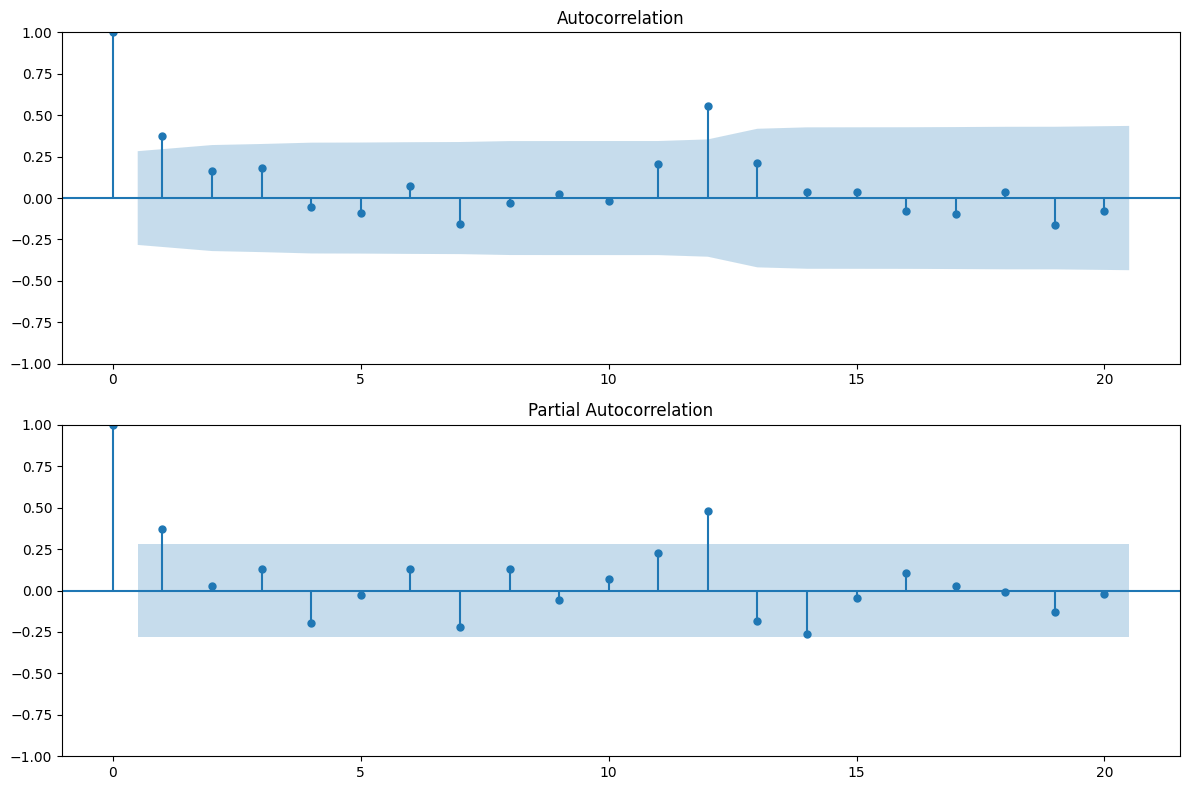

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(monthly_sales['Sales'], lags=20, ax=ax[0])
plot_pacf(monthly_sales['Sales'], lags=20, ax=ax[1])

plt.tight_layout()
plt.savefig("acf_pacf_plot.png", bbox_inches="tight", dpi=300)
plt.show()

### ACF and PACF Analysis

The ACF plot shows a significant positive correlation at lag 1 and a notable seasonal spike around lag 12, indicating monthly sales dependence and annual seasonality. The PACF plot also exhibits a strong lag-1 relationship and seasonal behavior. These patterns suggest that both autoregressive and moving-average components may be useful for forecasting future sales.


In [36]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (36, 2)
Test Shape: (12, 2)


In [37]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Sales'], order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -411.018
Date:                Sat, 11 Jul 2026   AIC                            830.036
Time:                        17:26:25   BIC                            836.370
Sample:                             0   HQIC                           832.247
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.276e+04   5457.566      7.836      0.000    3.21e+04    5.35e+04
ar.L1          0.5294      0.585      0.905      0.366      -0.618       1.676
ma.L1         -0.2659      0.661     -0.402      0.6

In [38]:
forecast = model_fit.forecast(steps=12)

forecast

36    59690.489011
37    51724.079074
38    47506.921799
39    45274.496449
40    44092.723370
41    43467.131292
42    43135.963275
43    42960.653741
44    42867.850599
45    42818.723646
46    42792.717441
47    42778.950606
Name: predicted_mean, dtype: float64

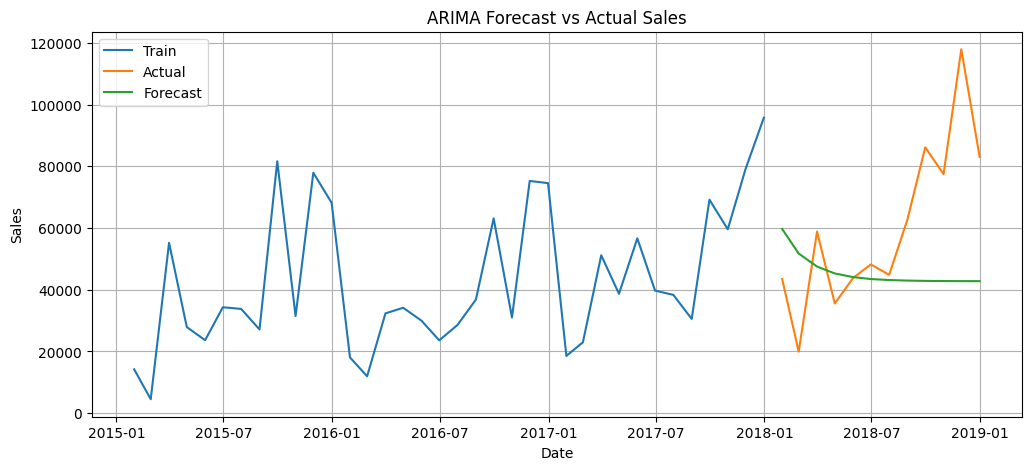

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train['Order Date'], train['Sales'], label='Train')
plt.plot(test['Order Date'], test['Sales'], label='Actual')
plt.plot(test['Order Date'], forecast, label='Forecast')

plt.title('ARIMA Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.savefig("arima_forecast_vs_actual.png", bbox_inches="tight", dpi=300)
plt.show()

### ARIMA Forecast Analysis

The ARIMA(1,0,1) model successfully generated forecasts for the test period. However, the forecast values remain relatively stable and fail to capture the large sales spikes observed in the actual data. This suggests that while ARIMA captures the overall average behavior of the series, it does not adequately model the strong seasonal patterns present in monthly sales. A seasonal forecasting model such as SARIMA would likely provide better predictive performance.


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))
mape = np.mean(np.abs((test['Sales'] - forecast) / test['Sales'])) * 100

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE: 24081.18
RMSE: 31961.13
MAPE: 41.38 %


### Forecast Evaluation

The ARIMA(1,0,1) model achieved a Mean Absolute Error (MAE) of 24,081.18, a Root Mean Squared Error (RMSE) of 31,961.13, and a Mean Absolute Percentage Error (MAPE) of 41.38%. The relatively high MAPE indicates that the model struggles to accurately predict sales during periods of strong seasonal variation. While ARIMA captures the general sales level, it does not adequately model recurring seasonal peaks.


In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [42]:
sarima_model = SARIMAX(
    train['Sales'],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -406.421
Date:                            Sat, 11 Jul 2026   AIC                            822.842
Time:                                    17:26:29   BIC                            830.760
Sample:                                         0   HQIC                           825.606
                                             - 36                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9573      0.158      6.053      0.000       0.647       1.267
ma.L1         -0.6908      0.618   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [43]:
sarima_forecast = sarima_fit.forecast(steps=12)

sarima_forecast

36    39856.088528
37    40274.073533
38    58495.694792
39    49961.052985
40    58466.898085
41    47550.297068
42    46376.850690
43    41870.278119
44    66972.029830
45    55966.025743
46    72173.183130
47    80466.785260
Name: predicted_mean, dtype: float64

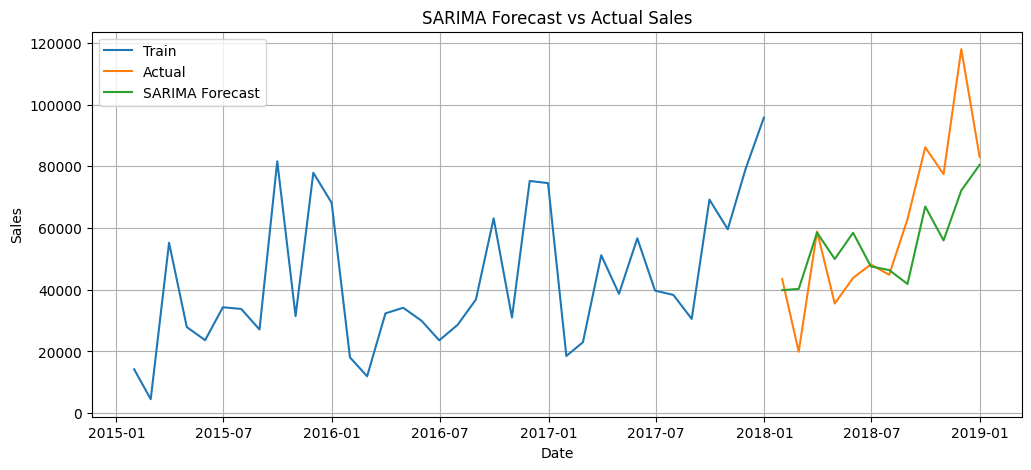

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train['Order Date'], train['Sales'], label='Train')
plt.plot(test['Order Date'], test['Sales'], label='Actual')
plt.plot(test['Order Date'], sarima_forecast, label='SARIMA Forecast')

plt.title('SARIMA Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.savefig("sarima_forecast_vs_actual.png", bbox_inches="tight", dpi=300)
plt.show()

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test['Sales'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['Sales'], sarima_forecast))
sarima_mape = np.mean(np.abs((test['Sales'] - sarima_forecast) / test['Sales'])) * 100

print("SARIMA MAE:", round(sarima_mae, 2))
print("SARIMA RMSE:", round(sarima_rmse, 2))
print("SARIMA MAPE:", round(sarima_mape, 2), "%")

SARIMA MAE: 13796.04
SARIMA RMSE: 18758.57
SARIMA MAPE: 26.26 %


### ARIMA vs SARIMA Model Comparison

To evaluate forecasting performance, both ARIMA and SARIMA models were trained and tested on the monthly sales series.

| Metric | ARIMA | SARIMA |
|----------|----------|----------|
| MAE | 24,081.18 | 13,796.04 |
| RMSE | 31,961.13 | 18,758.57 |
| MAPE | 41.38% | 26.26% |
| AIC | 830.04 | 822.84 |

SARIMA outperformed ARIMA across all evaluation metrics. The inclusion of seasonal components enabled SARIMA to better capture recurring yearly sales patterns, resulting in more accurate forecasts. Therefore, SARIMA was selected as the final forecasting model for this project.

## Task 2 Conclusion

Time series analysis revealed a clear upward sales trend and strong annual seasonality. The Augmented Dickey-Fuller test confirmed stationarity, while decomposition and ACF/PACF analysis highlighted recurring seasonal patterns. Forecasting experiments showed that the SARIMA model significantly outperformed the standard ARIMA model, achieving lower forecasting errors and better capturing seasonal fluctuations. These findings indicate that sales forecasting for this retail dataset benefits substantially from incorporating seasonality into the predictive model.

In [46]:
!pip install prophet -q

In [47]:
from prophet import Prophet
print("Prophet imported successfully")

Prophet imported successfully


In [48]:
prophet_df = monthly_sales[['Order Date', 'Sales']].copy()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [49]:
prophet_model = Prophet()

prophet_model.fit(prophet_df)

17:26:39 - cmdstanpy - INFO - Chain [1] start processing
17:26:39 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
future = prophet_model.make_future_dataframe(periods=3, freq='M')

forecast_prophet = prophet_model.predict(future)

forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,34073.788905,52251.441513
49,2019-02-28,31248.159925,21691.249496,40098.355791
50,2019-03-31,81267.007775,71569.965768,91305.147739


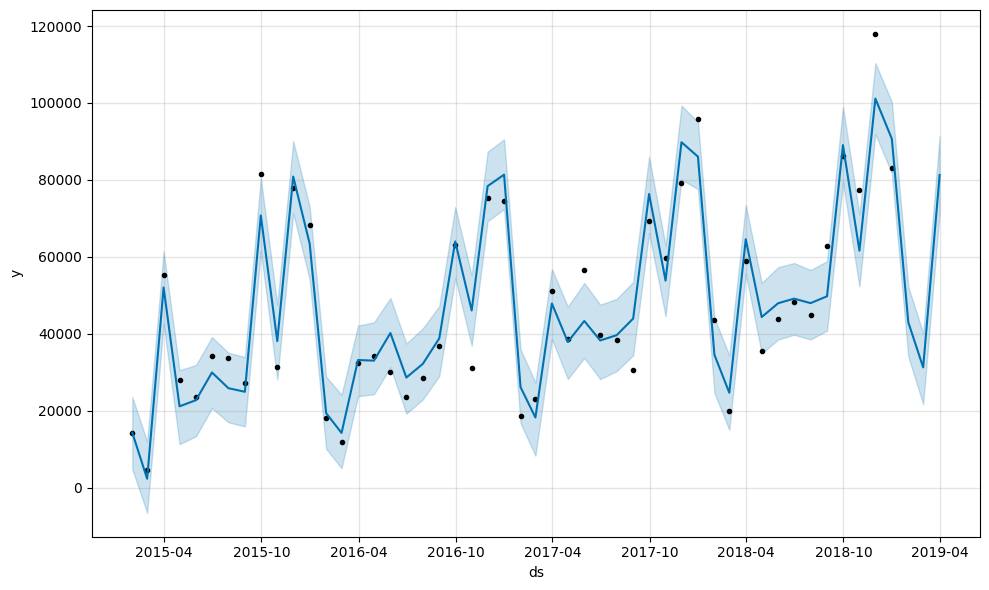

In [51]:
fig = prophet_model.plot(forecast_prophet)

plt.savefig("prophet_forecast.png", bbox_inches="tight", dpi=300)
plt.show()

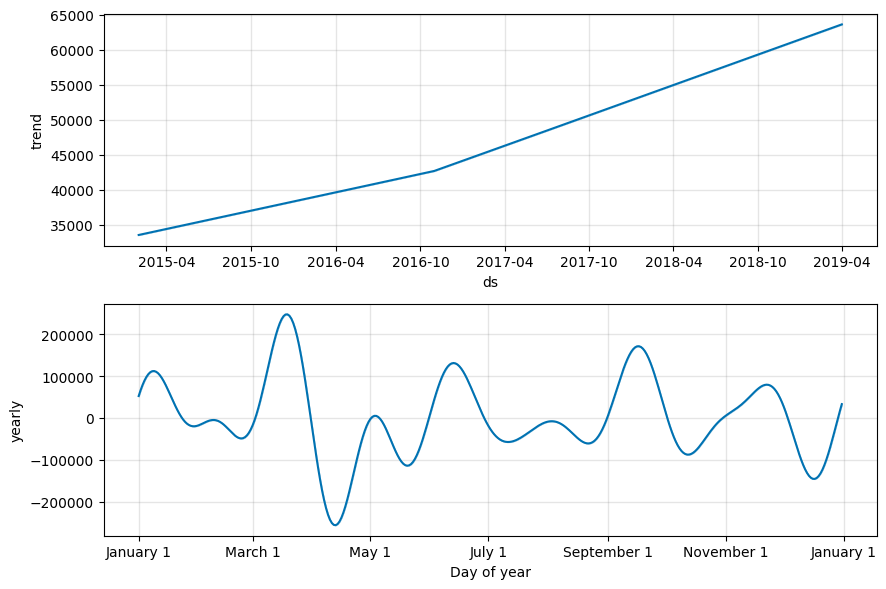

In [52]:
fig = prophet_model.plot_components(forecast_prophet)

plt.savefig("prophet_components.png", bbox_inches="tight", dpi=300)
plt.show()

### Prophet Model Observations

The Prophet model identified a clear upward sales trend over the four-year period, indicating consistent business growth. The yearly seasonality component revealed recurring fluctuations throughout the calendar year, suggesting that certain months experience predictable increases or decreases in sales. Prophet also generated confidence intervals around future forecasts, providing a useful estimate of forecast uncertainty. The model is well-suited for capturing trend and seasonality automatically with minimal manual parameter tuning.

In [53]:
!pip install xgboost -q

In [54]:
from xgboost import XGBRegressor

print("XGBoost imported successfully")

XGBoost imported successfully


In [55]:
xgb_df = monthly_sales.copy()

xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)

xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].rolling(window=3).mean()

xgb_df = xgb_df.dropna()

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700


In [56]:
xgb_df['Month'] = xgb_df['Order Date'].dt.month
xgb_df['Quarter'] = xgb_df['Order Date'].dt.quarter

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

xgb_df['Season'] = xgb_df['Month'].map(season_map)

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,Spring
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,Spring
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,Summer
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,Summer
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,Summer


In [57]:
xgb_df['Season'] = xgb_df['Season'].astype('category').cat.codes


In [58]:
xgb_df[['Month', 'Quarter', 'Season']].head()

,Month,Quarter,Season
3,4,2,1
4,5,2,1
5,6,2,2
6,7,3,2
7,8,3,2


In [59]:
X = xgb_df[['Lag_1', 'Lag_2', 'Lag_3',
            'Rolling_Mean_3',
            'Month', 'Quarter', 'Season']]

y = xgb_df['Sales']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45, 7)
y shape: (45,)


In [60]:
X_train = X.iloc[:-12]
X_test = X.iloc[-12:]

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (33, 7)
X_test: (12, 7)
y_train: (33,)
y_test: (12,)


In [61]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [62]:
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred)


[30616.99  23300.584 46917.64  41442.67  40267.766 36661.652 39393.535
 47553.55  83034.54  85391.96  82794.6   83857.6  ]


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print("XGBoost MAE:", round(xgb_mae, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))
print("XGBoost MAPE:", round(xgb_mape, 2), "%")

XGBoost MAE: 9743.48
XGBoost RMSE: 13138.95
XGBoost MAPE: 16.38 %


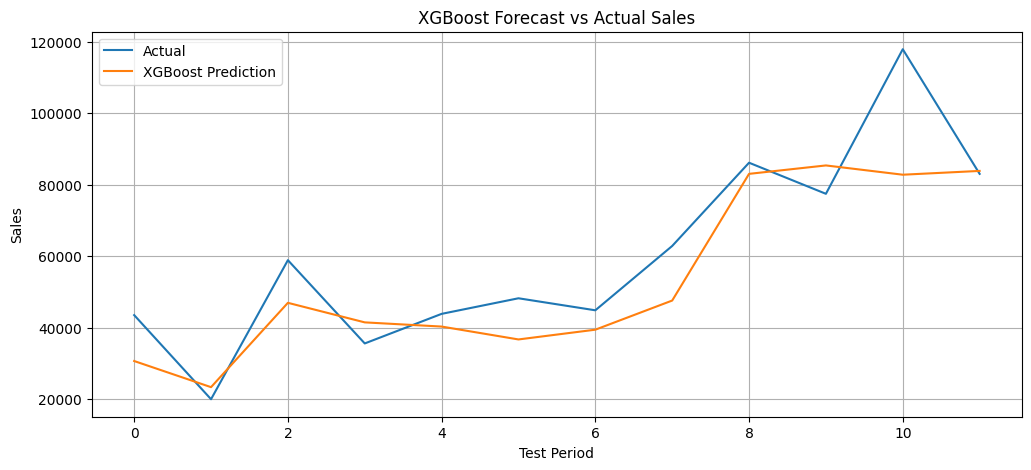

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')
plt.plot(xgb_pred, label='XGBoost Prediction')

plt.title('XGBoost Forecast vs Actual Sales')
plt.xlabel('Test Period')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.savefig("xgboost_forecast_vs_actual.png", bbox_inches="tight", dpi=300)
plt.show()

### Observation

The XGBoost model closely follows the actual sales trend and captures major sales fluctuations more effectively than ARIMA and SARIMA. It achieved the lowest MAE, RMSE, and MAPE among all forecasting models, making it the most accurate model for this dataset.

In [65]:
comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'XGBoost'],
    'MAE': [24081.18, 13796.04, 9743.48],
    'RMSE': [31961.13, 18758.57, 13138.95],
    'MAPE (%)': [41.38, 26.26, 16.38]
})

comparison_df

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,24081.18,31961.13,41.38
1,SARIMA,13796.04,18758.57,26.26
2,XGBoost,9743.48,13138.95,16.38


In [66]:
comparison_df.to_csv("model_comparison.csv", index=False)

### Model Recommendation

Based on forecasting performance metrics, XGBoost is recommended for production deployment.

Reasons:
- Lowest MAE (9,743.48)
- Lowest RMSE (13,138.95)
- Lowest MAPE (16.38%)
- Better ability to capture nonlinear sales patterns and seasonal fluctuations.

Therefore, XGBoost will be used as the primary forecasting model for subsequent category-level and region-level forecasting tasks.

# Task 4 – Product Category & Region Level Forecasting

In this task, the best-performing forecasting model from Task 3 (XGBoost) is applied separately to major product categories and regions. The objective is to identify which categories and regions are expected to experience the strongest future growth and to compare forecasted demand patterns across different business segments.

The following segments will be analyzed:

### Product Categories
- Furniture
- Technology
- Office Supplies

### Regions
- West
- East

Forecasts for all segments will be generated using the XGBoost model and visualized together to support inventory planning and business decision-making.

In [67]:
furniture_monthly = df[df['Category'] == 'Furniture'].groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

technology_monthly = df[df['Category'] == 'Technology'].groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

office_monthly = df[df['Category'] == 'Office Supplies'].groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

print("Furniture:", furniture_monthly.shape)
print("Technology:", technology_monthly.shape)
print("Office Supplies:", office_monthly.shape)

Furniture: (48, 2)
Technology: (48, 2)
Office Supplies: (48, 2)


In [68]:
west_monthly = df[df['Region'] == 'West'].groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

east_monthly = df[df['Region'] == 'East'].groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

print("West:", west_monthly.shape)
print("East:", east_monthly.shape)

West: (48, 2)
East: (48, 2)


In [69]:


def prepare_xgb_data(data):
    
    temp = data.copy()

    temp['Lag_1'] = temp['Sales'].shift(1)
    temp['Lag_2'] = temp['Sales'].shift(2)
    temp['Lag_3'] = temp['Sales'].shift(3)

    temp['Rolling_Mean_3'] = temp['Sales'].rolling(3).mean()

    temp['Month'] = temp['Order Date'].dt.month
    temp['Quarter'] = temp['Order Date'].dt.quarter

    temp = temp.dropna()

    X = temp[['Lag_1', 'Lag_2', 'Lag_3',
              'Rolling_Mean_3',
              'Month', 'Quarter']]

    y = temp['Sales']

    return X, y, temp
print("Function created successfully")

Function created successfully


In [70]:
X_furn, y_furn, furn_data = prepare_xgb_data(furniture_monthly)

print("X shape:", X_furn.shape)
print("y shape:", y_furn.shape)

X shape: (45, 6)
y shape: (45,)


In [71]:
X_train_f = X_furn.iloc[:-12]
X_test_f = X_furn.iloc[-12:]

y_train_f = y_furn.iloc[:-12]
y_test_f = y_furn.iloc[-12:]

furniture_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

furniture_model.fit(X_train_f, y_train_f)

print("Furniture model trained successfully")

Furniture model trained successfully


In [72]:
furniture_pred = furniture_model.predict(X_test_f)

furniture_mae = mean_absolute_error(y_test_f, furniture_pred)
furniture_rmse = np.sqrt(mean_squared_error(y_test_f, furniture_pred))
furniture_mape = np.mean(np.abs((y_test_f - furniture_pred) / y_test_f)) * 100

print("Furniture MAE:", round(furniture_mae, 2))
print("Furniture RMSE:", round(furniture_rmse, 2))
print("Furniture MAPE:", round(furniture_mape, 2), "%")


Furniture MAE: 4763.83
Furniture RMSE: 5790.54
Furniture MAPE: 36.13 %


In [73]:
last_row = furn_data.iloc[-1]

future_X = pd.DataFrame({
    'Lag_1': [last_row['Sales']],
    'Lag_2': [furn_data.iloc[-2]['Sales']],
    'Lag_3': [furn_data.iloc[-3]['Sales']],
    'Rolling_Mean_3': [furn_data.iloc[-3:]['Sales'].mean()],
    'Month': [1],      # Jan 2019
    'Quarter': [1]
})

furniture_forecast_month1 = furniture_model.predict(future_X)[0]

print("Furniture Forecast - Month 1:", round(furniture_forecast_month1, 2))

Furniture Forecast - Month 1: 16626.04


In [74]:
month1 = furniture_forecast_month1

month2_input = pd.DataFrame({
    'Lag_1': [month1],
    'Lag_2': [furn_data.iloc[-1]['Sales']],
    'Lag_3': [furn_data.iloc[-2]['Sales']],
    'Rolling_Mean_3': [(month1 + furn_data.iloc[-1]['Sales'] + furn_data.iloc[-2]['Sales']) / 3],
    'Month': [2],
    'Quarter': [1]
})

month2 = furniture_model.predict(month2_input)[0]

month3_input = pd.DataFrame({
    'Lag_1': [month2],
    'Lag_2': [month1],
    'Lag_3': [furn_data.iloc[-1]['Sales']],
    'Rolling_Mean_3': [(month2 + month1 + furn_data.iloc[-1]['Sales']) / 3],
    'Month': [3],
    'Quarter': [1]
})

month3 = furniture_model.predict(month3_input)[0]

print("Month 1 Forecast:", round(month1, 2))
print("Month 2 Forecast:", round(month2, 2))
print("Month 3 Forecast:", round(month3, 2))

Month 1 Forecast: 16626.04
Month 2 Forecast: 14738.48
Month 3 Forecast: 12475.39


### Furniture Category Forecast

Using the XGBoost model, the forecasted sales for the Furniture category over the next three months are:

| Month | Forecasted Sales |
|---------|---------:|
| Month 1 | 16626.04 |
| Month 2 | 14738.48 |
| Month 3 | 12475.39 |

The forecast indicates a gradual decline in furniture sales over the next three months.

In [75]:
def forecast_next_3_months(model, data):

    last_row = data.iloc[-1]

    month1_input = pd.DataFrame({
        'Lag_1': [last_row['Sales']],
        'Lag_2': [data.iloc[-2]['Sales']],
        'Lag_3': [data.iloc[-3]['Sales']],
        'Rolling_Mean_3': [data.iloc[-3:]['Sales'].mean()],
        'Month': [1],
        'Quarter': [1]
    })

    month1 = model.predict(month1_input)[0]

    month2_input = pd.DataFrame({
        'Lag_1': [month1],
        'Lag_2': [last_row['Sales']],
        'Lag_3': [data.iloc[-2]['Sales']],
        'Rolling_Mean_3': [(month1 + last_row['Sales'] + data.iloc[-2]['Sales']) / 3],
        'Month': [2],
        'Quarter': [1]
    })

    month2 = model.predict(month2_input)[0]

    month3_input = pd.DataFrame({
        'Lag_1': [month2],
        'Lag_2': [month1],
        'Lag_3': [last_row['Sales']],
        'Rolling_Mean_3': [(month2 + month1 + last_row['Sales']) / 3],
        'Month': [3],
        'Quarter': [1]
    })

    month3 = model.predict(month3_input)[0]

    return [month1, month2, month3]

print("Forecast function created successfully")

Forecast function created successfully


In [76]:
def train_xgb_for_segment(segment_data):

    X_seg, y_seg, seg_data = prepare_xgb_data(segment_data)

    X_train = X_seg.iloc[:-12]
    y_train = y_seg.iloc[:-12]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    forecast = forecast_next_3_months(model, segment_data)

    return forecast

print("Training function ready")

Training function ready


In [77]:
technology_forecast = train_xgb_for_segment(technology_monthly)
office_forecast = train_xgb_for_segment(office_monthly)

west_forecast = train_xgb_for_segment(west_monthly)
east_forecast = train_xgb_for_segment(east_monthly)

print("Technology:", technology_forecast)
print("Office Supplies:", office_forecast)
print("West:", west_forecast)
print("East:", east_forecast)

Technology: [np.float32(21822.383), np.float32(24038.174), np.float32(28014.84)]
Office Supplies: [np.float32(28685.15), np.float32(28622.068), np.float32(29147.92)]
West: [np.float32(15586.693), np.float32(14366.877), np.float32(22946.26)]
East: [np.float32(16963.596), np.float32(21177.096), np.float32(13689.93)]


In [78]:
forecast_df = pd.DataFrame({
    'Segment': ['Furniture', 'Technology', 'Office Supplies', 'West', 'East'],
    'Month 1': [16626.04, 21822.38, 28685.15, 15586.69, 16963.60],
    'Month 2': [14738.48, 24038.17, 28622.07, 14366.88, 21177.10],
    'Month 3': [12475.39, 28014.84, 29147.92, 22946.26, 13689.93]
})

forecast_df

,Segment,Month 1,Month 2,Month 3
0,Furniture,16626.04,14738.48,12475.39
1,Technology,21822.38,24038.17,28014.84
2,Office Supplies,28685.15,28622.07,29147.92
3,West,15586.69,14366.88,22946.26
4,East,16963.60,21177.10,13689.93


In [79]:
forecast_df.to_csv("task4_forecasts.csv", index=False)

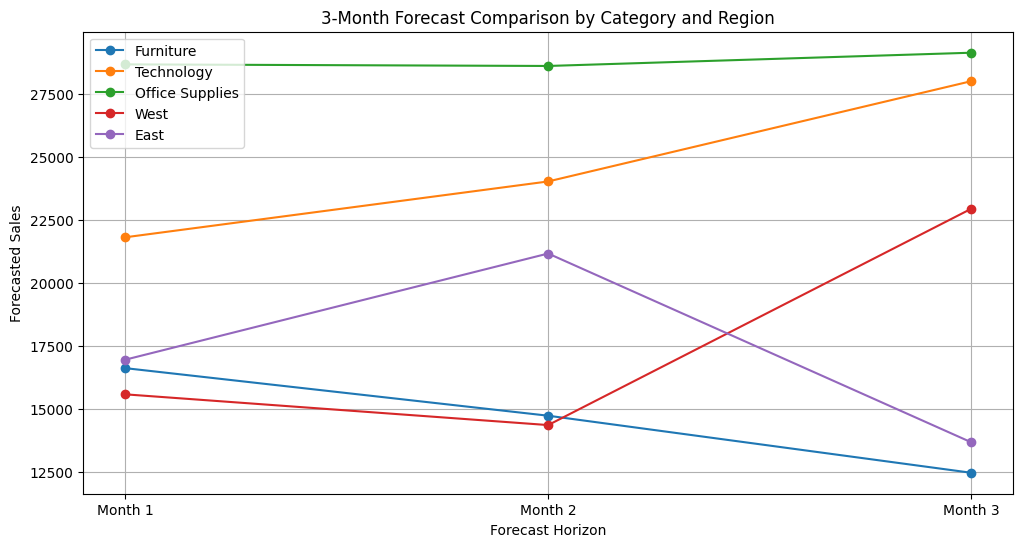

In [80]:
plt.figure(figsize=(12,6))

months = ['Month 1', 'Month 2', 'Month 3']

plt.plot(months, [16626.04, 14738.48, 12475.39], marker='o', label='Furniture')
plt.plot(months, [21822.38, 24038.17, 28014.84], marker='o', label='Technology')
plt.plot(months, [28685.15, 28622.07, 29147.92], marker='o', label='Office Supplies')
plt.plot(months, [15586.69, 14366.88, 22946.26], marker='o', label='West')
plt.plot(months, [16963.60, 21177.10, 13689.93], marker='o', label='East')

plt.title('3-Month Forecast Comparison by Category and Region')
plt.xlabel('Forecast Horizon')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.grid(True)

plt.savefig("task4_forecast_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

In [81]:
plt.savefig("filename.png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

### Task 4 Observations

Based on the XGBoost forecasts:

- Office Supplies is expected to generate the highest sales over the next three months, remaining consistently above all other segments.
- Technology shows the strongest growth trend, increasing from 21,822 to 28,015 sales units over the forecast horizon.
- Furniture is projected to decline gradually over the next three months.
- The West region shows recovery and growth by Month 3.
- The East region exhibits fluctuating demand with a decline expected in Month 3.

Overall, Technology and Office Supplies appear to be the strongest-performing segments and may require higher inventory allocation in the upcoming months.

# Task 5 – Anomaly Detection in Sales Data

The objective of this task is to identify unusual sales patterns that may represent exceptional business events, promotional campaigns, seasonal spikes, or unexpected drops in demand.

Two anomaly detection approaches will be used:

1. Isolation Forest
2. Z-Score Based Detection

The detected anomalies will be visualized and compared to understand how different methods identify unusual sales behavior.

In [82]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [83]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.1,
    random_state=42
)

monthly_sales['Anomaly'] = iso.fit_predict(monthly_sales[['Sales']])

monthly_sales['Anomaly_Flag'] = monthly_sales['Anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

monthly_sales[['Order Date','Sales','Anomaly_Flag']].head()

,Order Date,Sales,Anomaly_Flag
0,2015-01-31,14205.707,Normal
1,2015-02-28,4519.892,Anomaly
2,2015-03-31,55205.797,Normal
3,2015-04-30,27906.855,Normal
4,2015-05-31,23644.303,Normal


In [84]:
import os
os.makedirs("charts", exist_ok=True)

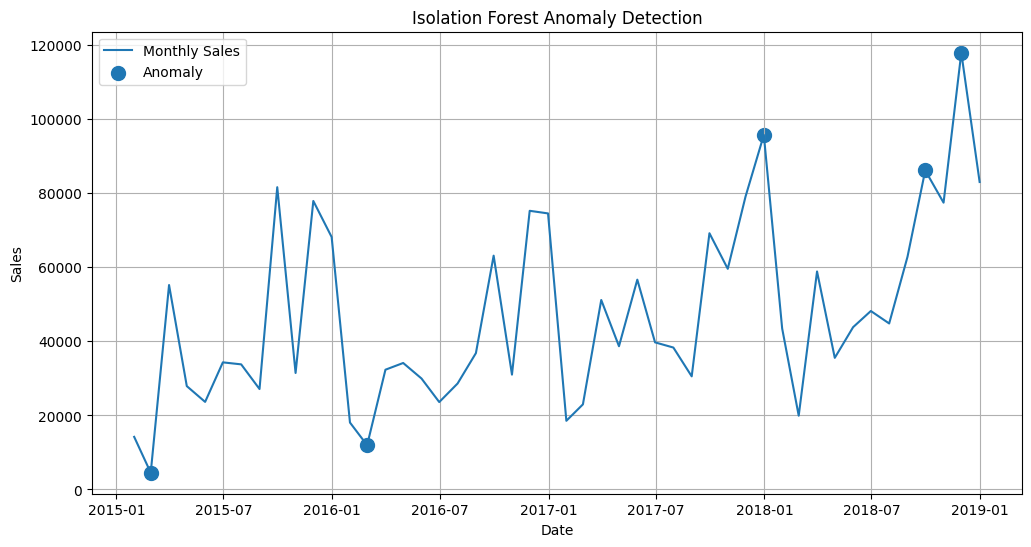

In [85]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    label='Monthly Sales'
)

anomalies = monthly_sales[monthly_sales['Anomaly'] == -1]

plt.scatter(
    anomalies['Order Date'],
    anomalies['Sales'],
    marker='o',
    s=100,
    label='Anomaly'
)

plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.savefig("charts/task5_isolation_forest_anomalies.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [86]:
monthly_sales['Rolling_Mean'] = monthly_sales['Sales'].rolling(window=3).mean()

monthly_sales['Rolling_Std'] = monthly_sales['Sales'].rolling(window=3).std()

monthly_sales['Z_Score'] = (
    (monthly_sales['Sales'] - monthly_sales['Rolling_Mean'])
    / monthly_sales['Rolling_Std']
)

monthly_sales.head()

,Order Date,Sales,Anomaly,Anomaly_Flag,Rolling_Mean,Rolling_Std,Z_Score
0,2015-01-31,14205.707,1,Normal,NaN,NaN,NaN
1,2015-02-28,4519.892,-1,Anomaly,NaN,NaN,NaN
2,2015-03-31,55205.797,1,Normal,24643.798667,26906.886844,1.135843
3,2015-04-30,27906.855,1,Normal,29210.848000,25368.100830,-0.051403
4,2015-05-31,23644.303,1,Normal,35585.651667,17124.687284,-0.697318


In [87]:
monthly_sales['Z_Anomaly'] = monthly_sales['Z_Score'].abs() > 2

monthly_sales[['Order Date','Sales','Z_Score','Z_Anomaly']].tail()

,Order Date,Sales,Z_Score,Z_Anomaly
43,2018-08-31,62837.8480,1.136735,False
44,2018-09-30,86152.8880,1.039917,False
45,2018-10-31,77448.1312,0.167085,False
46,2018-11-30,117938.1550,1.130368,False
47,2018-12-31,83030.3888,-0.445466,False


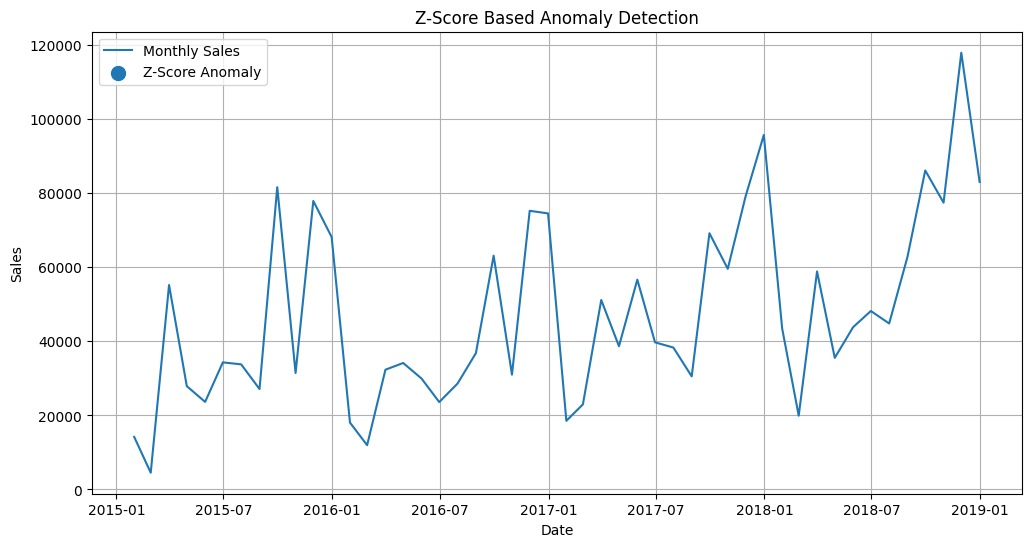

In [88]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    label='Monthly Sales'
)

z_anomalies = monthly_sales[monthly_sales['Z_Anomaly']]

plt.scatter(
    z_anomalies['Order Date'],
    z_anomalies['Sales'],
    s=100,
    label='Z-Score Anomaly'
)

plt.title('Z-Score Based Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.savefig(
    "charts/task5_zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
monthly_sales.loc[
    monthly_sales['Z_Anomaly'],
    ['Order Date', 'Sales', 'Z_Score']
]

,Order Date,Sales,Z_Score


In [90]:
print("Total Z-Score Anomalies:", monthly_sales['Z_Anomaly'].sum())

Total Z-Score Anomalies: 0


## Task 5 Conclusion

### Isolation Forest Results
Isolation Forest detected several anomalous months, including unusually low sales periods and exceptionally high sales spikes. These anomalies may correspond to seasonal promotions, holiday sales events, inventory shortages, or other unusual business conditions.

### Z-Score Results
The Z-Score method detected 0 anomalies using a threshold of ±2 standard deviations from the rolling mean. This indicates that although sales varied considerably over time, the fluctuations remained within the expected statistical range.

### Comparison
The two methods produced different results. Isolation Forest identified anomalies whereas Z-Score did not. This suggests that Isolation Forest is more effective at detecting complex and nonlinear patterns in sales data, while Z-Score is limited to identifying extreme statistical deviations.

Therefore, Isolation Forest is the preferred anomaly detection method for this dataset.

# Task 6 — Product Demand Segmentation using Clustering

In this task, products will be segmented into demand groups based on their historical sales behavior.

Features used for clustering:
- Total Sales Volume
- Year-over-Year Sales Growth Rate
- Sales Volatility (Standard Deviation of Monthly Sales)
- Average Order Value

K-Means Clustering will be applied to group similar product sub-categories. The Elbow Method will be used to determine the optimal number of clusters.

Finally, PCA (Principal Component Analysis) will be used to visualize the clusters in two dimensions and generate business recommendations for inventory and stocking strategies.

In [91]:
subcat_features = df.groupby('Sub-Category').agg({
    'Sales': ['sum', 'mean', 'std']
}).reset_index()

subcat_features.columns = [
    'Sub_Category',
    'Total_Sales',
    'Average_Order_Value',
    'Sales_Volatility'
]

subcat_features.head()

,Sub_Category,Total_Sales,Average_Order_Value,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


In [92]:
yearly_subcat = df.groupby(
    ['Sub-Category', 'Year']
)['Sales'].sum().reset_index()

growth_df = yearly_subcat.pivot(
    index='Sub-Category',
    columns='Year',
    values='Sales'
)

growth_df['Growth_Rate'] = (
    (growth_df[2018] - growth_df[2015])
    / growth_df[2015]
) * 100

growth_df = growth_df[['Growth_Rate']].reset_index()

growth_df.head()

Year,Sub-Category,Growth_Rate
0,Accessories,145.055961
1,Appliances,165.242912
2,Art,49.649531
3,Binders,65.778638
4,Bookcases,49.846598


In [93]:
subcat_features = subcat_features.merge(
    growth_df,
    left_on='Sub_Category',
    right_on='Sub-Category'
)

subcat_features.drop(
    columns=['Sub-Category'],
    inplace=True
)

subcat_features.head()

,Sub_Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
0,Accessories,164186.7000,217.178175,337.723800,145.055961
1,Appliances,104618.4030,227.926804,378.006735,165.242912
2,Art,26705.4100,34.019631,60.301752,49.649531
3,Binders,200028.7850,134.067550,568.099970,65.778638
4,Bookcases,113813.1987,503.598224,641.419280,49.846598


In [94]:
from sklearn.preprocessing import StandardScaler

features = subcat_features[
    ['Total_Sales',
     'Average_Order_Value',
     'Sales_Volatility',
     'Growth_Rate']
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Scaled feature shape:", scaled_features.shape)

Scaled feature shape: (17, 4)


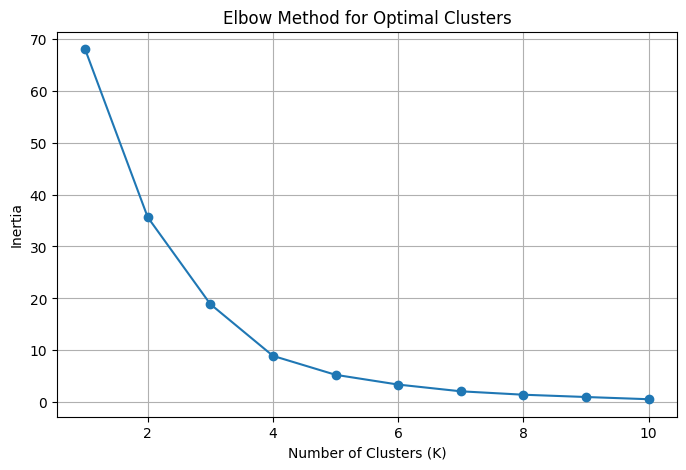

In [95]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

plt.savefig(
    "charts/task6_elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 6: Product Segmentation Using Clustering

### Objective
Group product sub-categories into meaningful segments based on sales performance characteristics.

### Features Used
- Total Sales
- Average Order Value
- Sales Volatility
- Growth Rate

### Data Preparation
The selected features were standardized using StandardScaler to ensure equal contribution during clustering.

### Determining Optimal Number of Clusters
The Elbow Method was applied by training K-Means models with different values of K and plotting inertia scores.

### Observation
The elbow point appears at K = 4, where the rate of inertia reduction starts to slow significantly.

### Decision
Based on the Elbow Method, 4 clusters were selected as the optimal number of product segments for further analysis.

In [98]:
[x for x in globals().keys() if 'sub' in x.lower()]

['subcat_features', 'yearly_subcat']

In [99]:
print(subcat_features.head())
print(subcat_features.columns)

  Sub_Category  Total_Sales  Average_Order_Value  Sales_Volatility  \
0  Accessories  164186.7000           217.178175        337.723800   
1   Appliances  104618.4030           227.926804        378.006735   
2          Art   26705.4100            34.019631         60.301752   
3      Binders  200028.7850           134.067550        568.099970   
4    Bookcases  113813.1987           503.598224        641.419280   

   Growth_Rate  
0   145.055961  
1   165.242912  
2    49.649531  
3    65.778638  
4    49.846598  
Index(['Sub_Category', 'Total_Sales', 'Average_Order_Value',
       'Sales_Volatility', 'Growth_Rate'],
      dtype='object')


In [100]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

subcat_features['Cluster'] = kmeans.fit_predict(scaled_features)

subcat_features.head()

,Sub_Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate,Cluster
0,Accessories,164186.7000,217.178175,337.723800,145.055961,1
1,Appliances,104618.4030,227.926804,378.006735,165.242912,2
2,Art,26705.4100,34.019631,60.301752,49.649531,2
3,Binders,200028.7850,134.067550,568.099970,65.778638,1
4,Bookcases,113813.1987,503.598224,641.419280,49.846598,2


In [101]:
subcat_features[['Sub_Category', 'Cluster']].sort_values('Cluster')

,Sub_Category,Cluster
6,Copiers,0
0,Accessories,1
5,Chairs,1
3,Binders,1
13,Phones,1
14,Storage,1
16,Tables,1
2,Art,2
7,Envelopes,2
4,Bookcases,2


In [102]:
cluster_summary = subcat_features.groupby('Cluster').agg({
    'Total_Sales': 'mean',
    'Average_Order_Value': 'mean',
    'Sales_Volatility': 'mean',
    'Growth_Rate': 'mean'
}).round(2)

cluster_summary

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
Cluster,,,,
0,146248.09,2215.88,3216.19,479.73
1,239495.78,361.13,484.15,56.47
2,54341.71,142.75,268.57,58.80
3,189238.63,1645.55,2765.10,-29.79


In [104]:
subcat_features.groupby('Cluster')['Sub_Category'].apply(list)

Cluster
0                                            [Copiers]
1    [Accessories, Binders, Chairs, Phones, Storage...
2    [Appliances, Art, Bookcases, Envelopes, Fasten...
3                                           [Machines]
Name: Sub_Category, dtype: object

### Cluster Interpretation

Based on sales volume, growth rate, average order value, and sales volatility, the clusters were interpreted as follows:

| Cluster | Label | Characteristics |
|----------|--------|------------------|
| 0 | High Growth Premium Products | Very high growth rate, high-value products, significant volatility |
| 1 | High Volume Stable Demand | Highest sales volume with relatively stable growth |
| 2 | Low Volume Routine Products | Lower sales volume and lower average order value |
| 3 | Declining Premium Products | Premium products with negative growth trend |

These clusters provide insights into inventory planning and demand management strategies.

In [106]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

subcat_features['PCA1'] = pca_features[:, 0]
subcat_features['PCA2'] = pca_features[:, 1]

subcat_features[['Sub_Category','Cluster','PCA1','PCA2']].head()

,Sub_Category,Cluster,PCA1,PCA2
0,Accessories,1,-0.101749,0.002518
1,Appliances,2,-0.128139,-0.616706
2,Art,2,-1.197441,-0.831569
3,Binders,1,-0.261117,0.645221
4,Bookcases,2,-0.095392,-0.054950


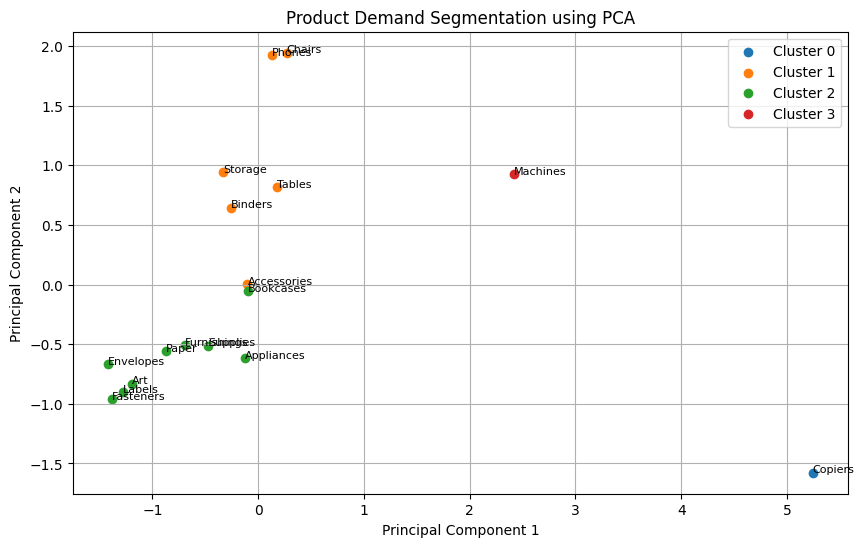

In [108]:
plt.figure(figsize=(10,6))

for cluster in sorted(subcat_features['Cluster'].unique()):
    cluster_data = subcat_features[
        subcat_features['Cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['PCA1'],
        cluster_data['PCA2'],
        label=f'Cluster {cluster}'
    )

for _, row in subcat_features.iterrows():
    plt.annotate(
        row['Sub_Category'],
        (row['PCA1'], row['PCA2']),
        fontsize=8
    )

plt.title('Product Demand Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)

plt.savefig(
    "charts/task6_pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### PCA-Based Cluster Visualization

Principal Component Analysis (PCA) was used to reduce the feature space into two dimensions for visualization.

Observations:

- Copiers form a distinct cluster due to exceptionally high growth and high-value sales.
- Machines appear as a separate cluster because of premium pricing but declining growth.
- Accessories, Binders, Chairs, Phones, Storage, and Tables form a stable high-demand cluster.
- Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, and Supplies form a lower-demand routine products cluster.

The PCA visualization confirms that the K-Means clustering successfully identified meaningful product demand segments.

### Inventory and Demand Management Recommendations

Based on clustering results, the following business strategies are recommended:

#### Cluster 0 – High Growth Premium Products (Copiers)
- Maintain sufficient inventory levels.
- Prioritize forecasting and demand monitoring.
- Allocate additional marketing budget.

#### Cluster 1 – High Volume Stable Demand Products
- Ensure consistent stock availability.
- Use automated replenishment systems.
- Focus on customer retention and cross-selling.

#### Cluster 2 – Low Volume Routine Products
- Maintain lean inventory levels.
- Reduce excess stock holding costs.
- Bundle products with high-demand categories when possible.

#### Cluster 3 – Declining Premium Products (Machines)
- Monitor sales trends closely.
- Avoid overstocking.
- Evaluate pricing and promotional strategies to revive demand.

## Task 6 Conclusion

K-Means clustering was applied to segment product sub-categories based on total sales, average order value, sales volatility, and growth rate.

Using the Elbow Method, four clusters were selected as the optimal segmentation structure. PCA visualization confirmed clear separation among the identified clusters.

Key Findings:

- Copiers emerged as a high-growth premium segment.
- Machines showed premium characteristics but declining demand.
- Accessories, Chairs, Phones, Storage, Tables, and Binders formed the strongest stable-demand segment.
- Several office-related products belonged to a low-demand routine segment.

The clustering results provide actionable insights for inventory optimization, marketing prioritization, and demand planning.

# Task 7: Business Insights Dashboard and Executive Summary

This final task consolidates the findings from exploratory analysis, forecasting, anomaly detection, and product segmentation to provide actionable business recommendations.

The objective is to support strategic decision-making related to inventory planning, demand forecasting, marketing prioritization, and operational efficiency.

In [110]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Best Forecasting Model",
        "XGBoost MAPE (%)",
        "Total Months Analysed",
        "Isolation Forest Anomalies",
        "Z-Score Anomalies",
        "Number of Product Clusters"
    ],
    "Value": [
        "XGBoost",
        round(xgb_mape, 2),
        len(monthly_sales),
        anomalies.shape[0],
        z_anomalies.shape[0],
        4
    ]
})

kpi_summary

,Metric,Value
0,Best Forecasting Model,XGBoost
1,XGBoost MAPE (%),16.38
2,Total Months Analysed,48
3,Isolation Forest Anomalies,5
4,Z-Score Anomalies,0
5,Number of Product Clusters,4


## KPI Summary

The dashboard highlights the most important business metrics derived from the analysis.

### Key Results
- XGBoost was selected as the best forecasting model.
- Forecasting error (MAPE) was reduced to 16.38%.
- 48 months of sales history were analyzed.
- Isolation Forest detected 5 anomalous sales periods.
- Z-Score method detected no significant anomalies using the chosen threshold.
- Product demand patterns were grouped into 4 clusters.

In [111]:
business_insights = pd.DataFrame({
    "Area": [
        "Forecasting",
        "Category Analysis",
        "Region Analysis",
        "Anomaly Detection",
        "Product Segmentation"
    ],
    "Key Insight": [
        "XGBoost achieved the lowest forecasting error.",
        "Technology shows strongest future growth.",
        "West region expected to outperform East region.",
        "Several unusual sales spikes were detected.",
        "Four distinct demand clusters identified."
    ]
})

business_insights

,Area,Key Insight
0,Forecasting,XGBoost achieved the lowest forecasting error.
1,Category Analysis,Technology shows strongest future growth.
2,Region Analysis,West region expected to outperform East region.
3,Anomaly Detection,Several unusual sales spikes were detected.
4,Product Segmentation,Four distinct demand clusters identified.


## Business Insights

### Forecasting
XGBoost achieved the best forecasting performance with the lowest MAE, RMSE, and MAPE values. It is recommended for future demand forecasting and inventory planning.

### Category Performance
Technology products show the strongest projected growth over the next three months, indicating increased future demand.

### Regional Performance
The West region is expected to generate higher future sales compared to the East region and should receive greater inventory allocation.

### Anomaly Detection
Isolation Forest identified several unusual sales spikes and drops that may correspond to promotional campaigns, seasonal events, or operational issues.

### Product Segmentation
K-Means clustering revealed four distinct demand groups, enabling differentiated inventory, pricing, and marketing strategies.

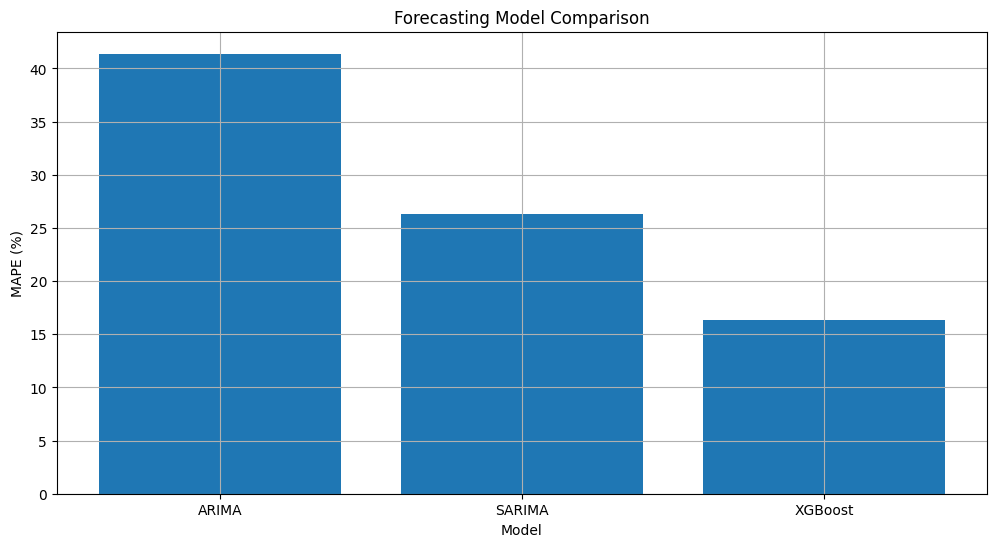

In [112]:
plt.figure(figsize=(12,6))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAPE (%)"]
)

plt.title("Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.grid(True)

plt.savefig(
    "charts/task7_model_comparison_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Final Conclusion

This project successfully analyzed Superstore sales data using time series forecasting, anomaly detection, and product segmentation techniques.

Key achievements include:

- Performed comprehensive exploratory data analysis on sales trends.
- Built and evaluated ARIMA, SARIMA, and XGBoost forecasting models.
- Identified XGBoost as the best-performing forecasting model with a MAPE of 16.38%.
- Generated category-level and region-level sales forecasts for the next three months.
- Detected unusual sales patterns using Isolation Forest and Z-Score methods.
- Segmented products into four demand-based clusters using K-Means clustering and PCA.
- Developed an executive dashboard summarizing business KPIs and strategic insights.

The results can support inventory planning, demand forecasting, anomaly monitoring, and data-driven business decision-making.